# Advanced Machine Learning for Motor Insurance Claim Prediction and Policyholder Profiling in Kenya


In this capstone, the question is deeper and has two parts:

1. **"What natural types of policyholders exist in this portfolio?"** → Unsupervised learning (K-Means clustering + PCA)
2. **"How much could this policyholder claim?"** → Supervised learning, regression (Linear Regression, Random Forest,
   Gradient Boosting, XGBoost, and a Neural Network), explained with SHAP.

The target variable  is **`Total_Claim_Amount_KES`**, a continuous value in Kenyan Shillings.

## Project Roadmap

| Part | Section | What we do | Why it matters |
|---|---|---|---|
| A | 1–4 | Load, clean, explore the data | Nothing downstream is trustworthy if this is wrong |
| B | 5 | Policyholder profiling with **K-Means** | Discovers natural customer segments, unsupervised |
| C | 6 | **PCA** | Compresses the feature space and visualizes cluster structure |
| D | 7–8 | Claim amount **regression** (5 models) | The core predictive task of this capstone |
| E | 9 | **Hyperparameter tuning** | Squeezes out extra performance, done properly with cross-validation |
| F | 10 | Model comparison & champion selection | Decide which model to trust, and why |
| G | 11 | **SHAP explainability** | Opens the "black box" of the champion model |
| H | 12 | Error analysis | Where does the champion model still struggle, and why |
| I | 13 | Conclusions & future work | What we learned, and what we'd do with more time/data |

> **A lesson carried over from ML Foundations:** every preprocessing step that *learns* something from data
> (scaling, encoding, PCA) is fitted **only on the training set**, then applied to the test set. This avoids
> the data leakage issue flagged in the previous project's feedback.

In [2]:
# ── Core libraries ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Unsupervised learning & dimensionality reduction ────────────────────────
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ── Preprocessing & model selection ─────────────────────────────────────────
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ── Supervised regression models ────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
import xgboost as xgb

# ── Deep learning ────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Evaluation ───────────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Explainability ───────────────────────────────────────────────────────────
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', None)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 1. Business Understanding

An insurer's two biggest questions about its motor book are usually:

- **"What kinds of customers do we actually have?"** — useful for designing products, marketing, and pricing tiers.
- **"How much is each policy likely to cost us in claims?"** — the foundation of fair, risk-based pricing.

This project answers both, using 2,000 Kenyan motor insurance policies from 2023–2024, covering private cars,
commercial vehicles, PSVs (public service vehicles, e.g. matatus) and motorcycles across 8 regions.

## 2. Data Understanding

Let's load the data and get a first look at its shape, types, and summary statistics.

In [3]:
df = pd.read_csv('Kenyan_Motor_Insurance_2023_2024.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 2000 rows, 19 columns


,Year,Policy_ID,Customer_Age,Gender,Region,Vehicle_Type,Vehicle_Age,Vehicle_Value_KES,Vehicle_Engine_Capacity,Use_Purpose,Annual_Premium_KES,Claims_Frequency,Total_Claim_Amount_KES,No_Claim_Bonus_%,Accident_Cause,Policy_Term_Months,Previous_Claims_Count,Driver_Experience_Years,Third_Party_Only
0,2023,P202300001,58,Male,Nakuru,PSV,19,3229084,2000,Business,203851,1,866500.0,0,Theft,6,0,38,Yes
1,2023,P202300002,43,Male,Thika,Private,3,1739911,2000,Taxi,64471,0,0.0,20,NaN,6,2,22,No
2,2023,P202300003,40,Male,Kakamega,Private,0,2781931,1500,Business,146378,0,0.0,50,NaN,12,0,22,Yes
3,2023,P202300004,46,Male,Nakuru,Private,9,1154811,2500,Personal,59810,0,0.0,30,NaN,12,0,26,No
4,2023,P202300005,63,Female,Nakuru,Commercial,19,3452991,1000,Business,143266,0,0.0,30,NaN,6,0,41,No


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     2000 non-null   int64  
 1   Policy_ID                2000 non-null   str    
 2   Customer_Age             2000 non-null   int64  
 3   Gender                   2000 non-null   str    
 4   Region                   2000 non-null   str    
 5   Vehicle_Type             2000 non-null   str    
 6   Vehicle_Age              2000 non-null   int64  
 7   Vehicle_Value_KES        2000 non-null   int64  
 8   Vehicle_Engine_Capacity  2000 non-null   int64  
 9   Use_Purpose              2000 non-null   str    
 10  Annual_Premium_KES       2000 non-null   int64  
 11  Claims_Frequency         2000 non-null   int64  
 12  Total_Claim_Amount_KES   2000 non-null   float64
 13  No_Claim_Bonus_%         2000 non-null   int64  
 14  Accident_Cause           662 non-nu

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,2000.0,NaN,NaN,NaN,2023.5,0.500125,2023.0,2023.0,2023.5,2024.0,2024.0
Policy_ID,2000,2000,P202300001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Age,2000.0,NaN,NaN,NaN,44.44,14.424577,20.0,32.0,44.0,57.0,69.0
Gender,2000,2,Male,1009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,2000,8,Nairobi,275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Type,2000,4,Private,991,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Age,2000.0,NaN,NaN,NaN,9.574,5.718205,0.0,5.0,10.0,15.0,19.0
Vehicle_Value_KES,2000.0,NaN,NaN,NaN,1993015.504,1167646.697425,50767.0,1114231.75,1942366.0,2757036.5,4984737.0
Vehicle_Engine_Capacity,2000.0,NaN,NaN,NaN,2023.25,700.770988,1000.0,1500.0,2000.0,2500.0,3000.0
Use_Purpose,2000,3,Personal,1216,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Column reference**

| Column | Meaning |
|---|---|
| `Customer_Age`, `Gender`, `Region` | Policyholder demographics |
| `Vehicle_Type`, `Vehicle_Age`, `Vehicle_Value_KES`, `Vehicle_Engine_Capacity` | Vehicle characteristics |
| `Use_Purpose` | Personal, Business, or Taxi use |
| `Annual_Premium_KES` | What the policyholder pays per year |
| `No_Claim_Bonus_%` | Discount earned for a clean claims history |
| `Previous_Claims_Count` | Claims count *before* this policy period (historical) |
| `Policy_Term_Months`, `Third_Party_Only` | Policy structure |
| `Driver_Experience_Years` | Years the named driver has held a licence |
| `Claims_Frequency`, `Accident_Cause`, **`Total_Claim_Amount_KES`** | Outcomes *of this policy period* — the last one is our prediction target |

## 3. Data Cleaning

### 3.1 Missing values

In [6]:
missing = df.isna().sum()
missing = missing[missing > 0]
pd.DataFrame({
    'missing_count': missing,
    'missing_pct': (missing / len(df) * 100).round(1)
})

,missing_count,missing_pct
Accident_Cause,1338,66.9


Only **`Accident_Cause`** has missing values (1,338 of 2,000 rows — 66.9%). Before assuming anything, let's check
*when* it's missing.

In [7]:
# Does Accident_Cause go missing exactly when no claim was made?
pd.crosstab(df['Claims_Frequency'] == 0, df['Accident_Cause'].isna(),
            rownames=['Claims_Frequency == 0'], colnames=['Accident_Cause is missing'])

Accident_Cause is missing,False,True
Claims_Frequency == 0,,
False,662,0
True,0,1338


The match is **exact**: every single row with `Claims_Frequency == 0` has a missing `Accident_Cause`, and every row
with a recorded `Accident_Cause` has `Claims_Frequency > 0`. This isn't a data quality problem — a policy with no
claims simply has no accident to describe. We fill the missing values with the explicit label `"No Claim"` rather
than guessing a cause, which keeps the information (zero claims) visible to any model that uses this column.

> This is a cleaner situation than the `Accessories` column in the ML Foundations project, where a missing value
> was genuinely ambiguous (no accessories, vs. simply not recorded). Here the missingness is fully explained by another
> column, so filling it is not an assumption — it's confirmed by the data itself.

In [8]:
df['Accident_Cause'] = df['Accident_Cause'].fillna('No Claim')
print("Remaining missing values:", df.isna().sum().sum())

Remaining missing values: 0


### 3.2 Duplicates

In [9]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated Policy_ID values:", df['Policy_ID'].duplicated().sum())

Fully duplicated rows: 0
Duplicated Policy_ID values: 0


No duplicate rows or duplicate policy IDs — every record is a unique policy. Nothing to remove.

### 3.3 Outlier check

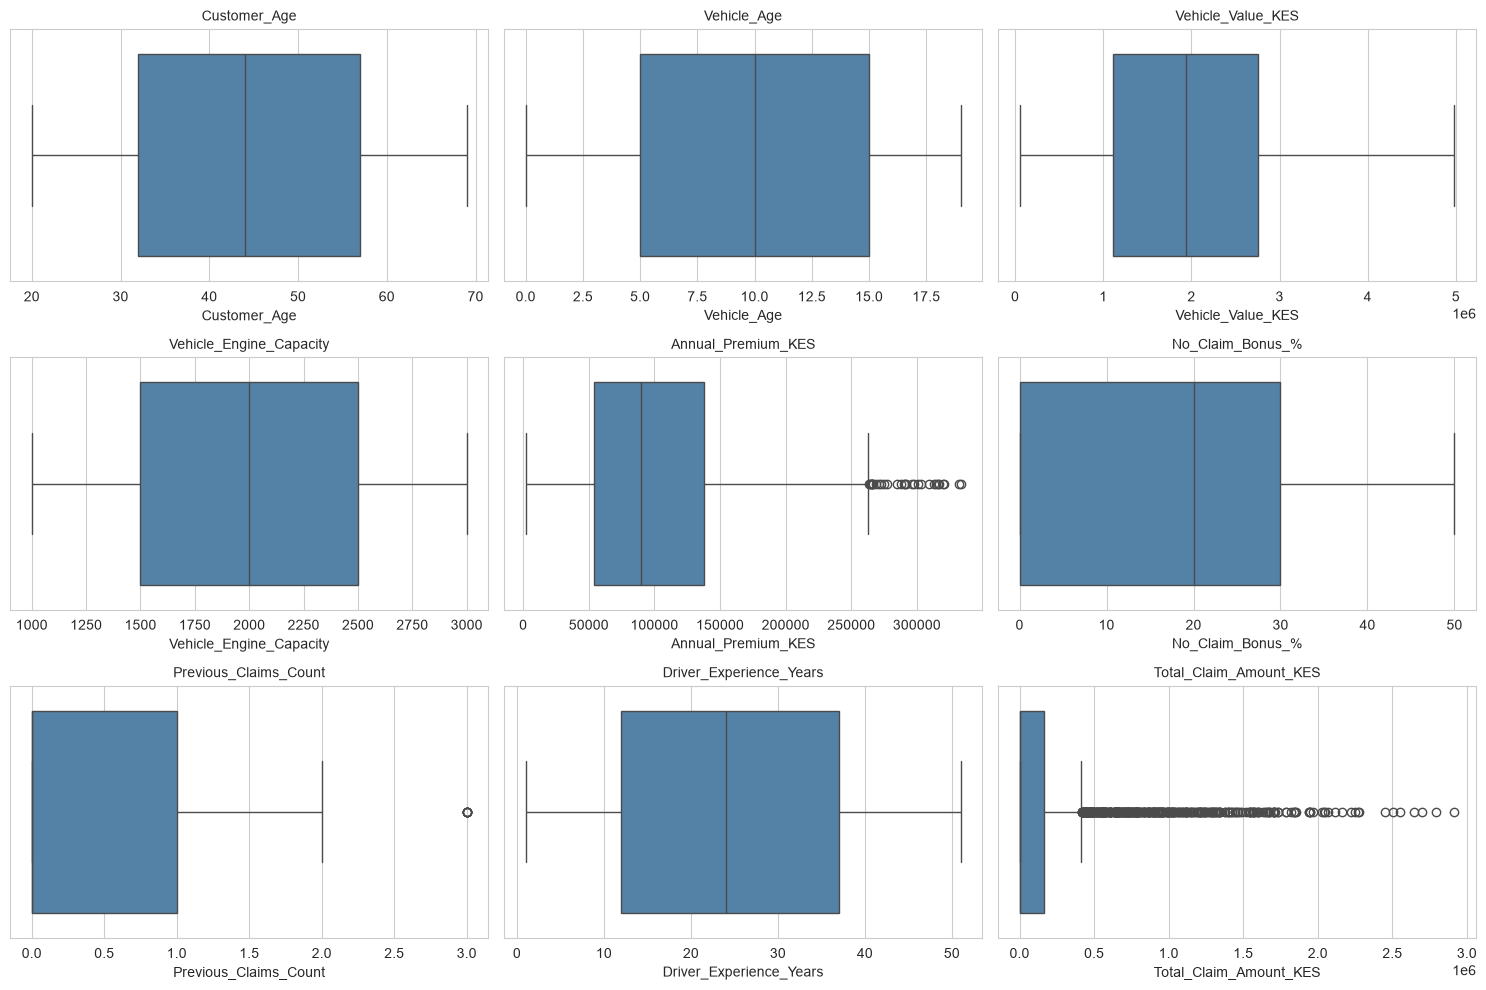

In [10]:
numeric_cols = ['Customer_Age', 'Vehicle_Age', 'Vehicle_Value_KES', 'Vehicle_Engine_Capacity',
                'Annual_Premium_KES', 'No_Claim_Bonus_%', 'Previous_Claims_Count',
                'Driver_Experience_Years', 'Total_Claim_Amount_KES']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(x=df[col], ax=ax, color='steelblue')
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

`Total_Claim_Amount_KES` and `Annual_Premium_KES` show long right tails — a handful of very large claims and premiums.
These are **not data errors**: large commercial/PSV vehicles genuinely carry higher values, premiums and potential
claim costs, so we keep them. We revisit this skew carefully in Section 7, since it affects how we read regression
performance.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Target variable: `Total_Claim_Amount_KES`

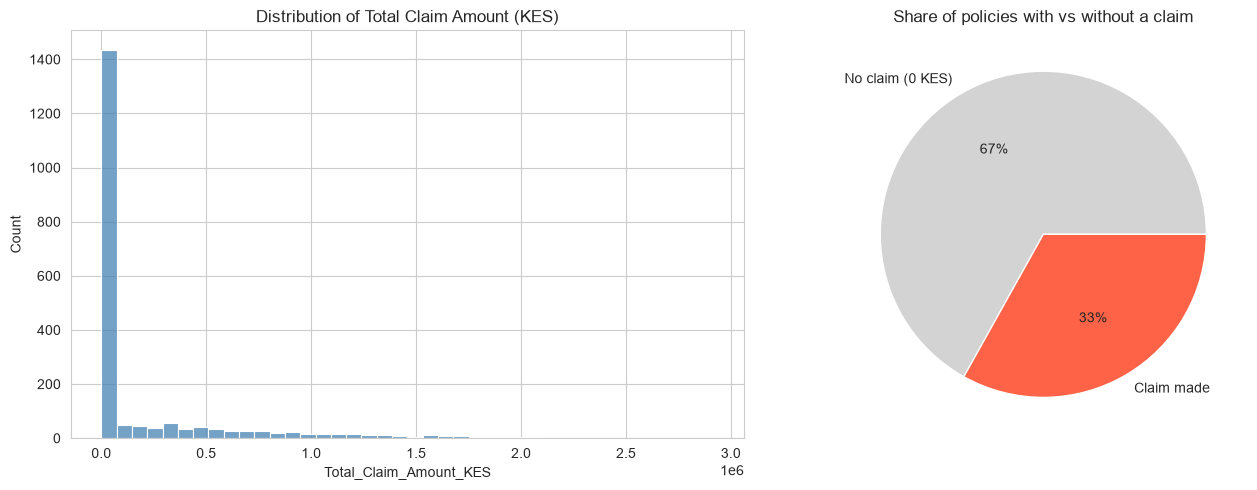

Policies with zero claims: 66.9%
count        662.0
mean      610228.0
std       553180.0
min         7000.0
25%       172200.0
50%       462800.0
75%       897650.0
max      2916800.0
Name: Total_Claim_Amount_KES, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Total_Claim_Amount_KES'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Total Claim Amount (KES)')

zero_share = (df['Total_Claim_Amount_KES'] == 0).mean()
sizes = [zero_share, 1 - zero_share]
axes[1].pie(sizes, labels=['No claim (0 KES)', 'Claim made'], autopct='%1.0f%%',
            colors=['lightgrey', 'tomato'])
axes[1].set_title('Share of policies with vs without a claim')
plt.tight_layout()
plt.show()

print(f"Policies with zero claims: {zero_share:.1%}")
print(df.loc[df['Total_Claim_Amount_KES'] > 0, 'Total_Claim_Amount_KES'].describe().round(0))

**This is the single most important fact about our target variable:** 66.9% of policies have **zero** claims. Among
the policies that *do* have a claim, the amount ranges widely (from 7,000 KES to nearly 2.9 million KES). This is a
classic **zero-inflated** distribution, and it will shape how we judge "good" model performance later — a model that
is simply bad at telling zero-claim policies apart from large-claim ones will still show a middling R², so we must
look beyond R² alone (Section 10).

### 4.2 Relationships between features and the target

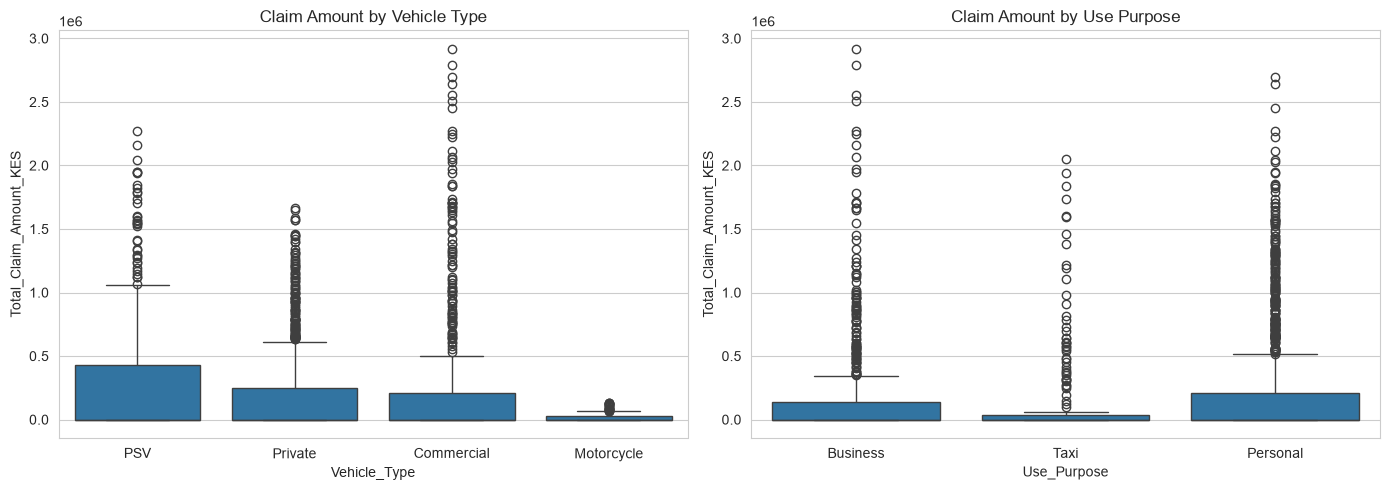

Vehicle_Type
PSV           283463.0
Commercial    283452.0
Private       173364.0
Motorcycle     18232.0
Name: Total_Claim_Amount_KES, dtype: float64

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Vehicle_Type', y='Total_Claim_Amount_KES', ax=axes[0])
axes[0].set_title('Claim Amount by Vehicle Type')
sns.boxplot(data=df, x='Use_Purpose', y='Total_Claim_Amount_KES', ax=axes[1])
axes[1].set_title('Claim Amount by Use Purpose')
plt.tight_layout()
plt.show()

df.groupby('Vehicle_Type')['Total_Claim_Amount_KES'].mean().sort_values(ascending=False).round(0)

**Commercial** and **PSV** vehicles have average claim amounts roughly 1.6x higher than Private vehicles, and
**Motorcycles** sit far lower — this matches real-world intuition: commercial/PSV vehicles are higher-value, more
exposed assets.

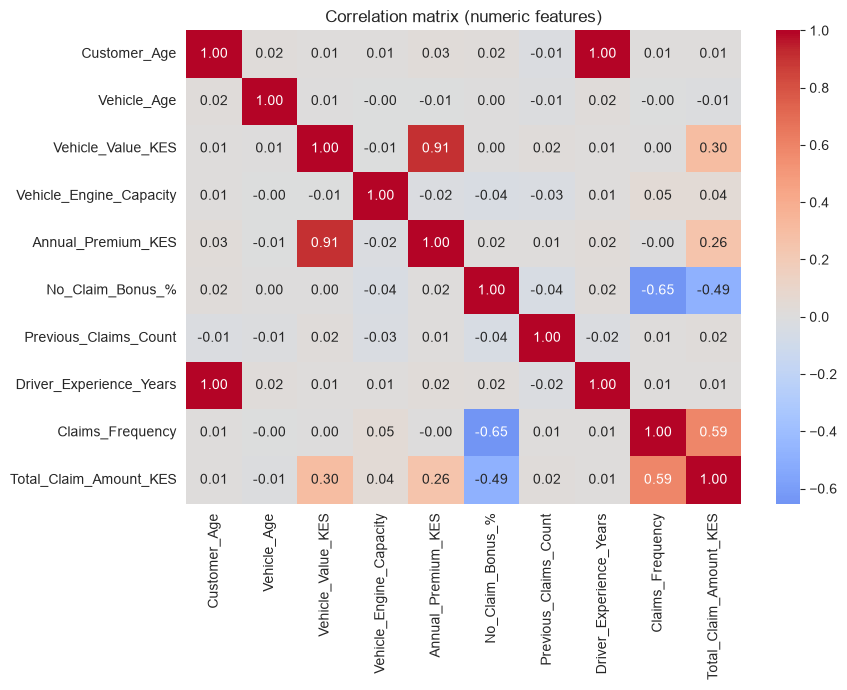

Claims_Frequency           0.592159
No_Claim_Bonus_%          -0.490245
Vehicle_Value_KES          0.297497
Annual_Premium_KES         0.256508
Vehicle_Engine_Capacity    0.040873
Previous_Claims_Count      0.023124
Vehicle_Age               -0.012845
Driver_Experience_Years    0.009166
Customer_Age               0.008432
Name: Total_Claim_Amount_KES, dtype: float64

In [13]:
num_corr_cols = ['Customer_Age', 'Vehicle_Age', 'Vehicle_Value_KES', 'Vehicle_Engine_Capacity',
                  'Annual_Premium_KES', 'No_Claim_Bonus_%', 'Previous_Claims_Count',
                  'Driver_Experience_Years', 'Claims_Frequency', 'Total_Claim_Amount_KES']
corr = df[num_corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix (numeric features)')
plt.tight_layout()
plt.show()

corr['Total_Claim_Amount_KES'].drop('Total_Claim_Amount_KES').sort_values(key=abs, ascending=False)

Three things stand out:

1. **`Claims_Frequency` correlates 0.59 with the target** — the strongest relationship in the dataset. But look closer:
2. **`Customer_Age` and `Driver_Experience_Years` are almost perfectly correlated with each other** (not surprising —
   older customers have held a licence longer). We'll treat this as redundant information during modelling.
3. **`No_Claim_Bonus_%` has a meaningful negative correlation (-0.49)** — policyholders with a bigger no-claims discount
   tend to have smaller claims. This is a *legitimate, known-at-renewal-time* signal, unlike `Claims_Frequency`
   (see the important caveat below).

### 4.3 A critical check: is `Claims_Frequency` leakage?

`Claims_Frequency` is **not** a demographic or policy-design feature — it is an *outcome of the same policy period*
we are trying to predict. Confirming this:

In [14]:
# Does Claims_Frequency == 0 perfectly predict Total_Claim_Amount_KES == 0?
check = pd.crosstab(df['Claims_Frequency'] == 0, df['Total_Claim_Amount_KES'] == 0)
check

Total_Claim_Amount_KES,False,True
Claims_Frequency,,
False,662,0
True,0,1338


Every policy with `Claims_Frequency == 0` has `Total_Claim_Amount_KES == 0`, and every policy with `Claims_Frequency > 0`
has a non-zero claim amount. **This is a near-deterministic relationship, not a genuine predictive signal** — a model
that is handed `Claims_Frequency` is basically being told the answer to "was there a claim?" before trying to also predict
"how much?" The same applies to `Accident_Cause`, since it is only known once a claim has occurred.

**Decision:** in Section 7, our main regression task uses only features that would realistically be known **when a
policy is underwritten** — before the policy period starts, and therefore before any claims happen. `Claims_Frequency`
and `Accident_Cause` are excluded from the predictors for that reason. We revisit this as a deliberate sensitivity
experiment in Section 7.4, rather than quietly dropping the columns — the difference it makes is itself an interesting
result.

## 5. Policyholder Profiling with K-Means Clustering

This is the **unsupervised learning** half of the project. The goal is to let the data reveal natural policyholder
groups — we do not decide the groups in advance.

### 5.1 Choosing the clustering features

We cluster on variables that **describe a policyholder and their vehicle**, not on outcomes of the policy period
(`Claims_Frequency`, `Total_Claim_Amount_KES`). Clustering on outcome variables would just reproduce claim/no-claim
groups rather than discover customer *types*. `Previous_Claims_Count` is kept, since it reflects *history before*
this policy period, not an outcome of it.

Clustering is performed on the **full dataset** (not a train/test split): unlike supervised learning, there is no
label to "leak", and the goal here is a descriptive segmentation of the whole portfolio, not a prediction for new,
unseen policyholders.

In [15]:
cluster_features = ['Customer_Age', 'Vehicle_Age', 'Vehicle_Value_KES', 'Vehicle_Engine_Capacity',
                    'Annual_Premium_KES', 'No_Claim_Bonus_%', 'Previous_Claims_Count',
                    'Driver_Experience_Years']

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df[cluster_features])
print(f"Clustering on {X_cluster.shape[1]} standardized features, {X_cluster.shape[0]} policyholders.")

Clustering on 8 standardized features, 2000 policyholders.


### 5.2 Choosing k: Elbow Method + Silhouette Score

We never pick k by instinct — we compute both the elbow curve (inertia) and the silhouette score for a range of k,
and justify our final choice against both.

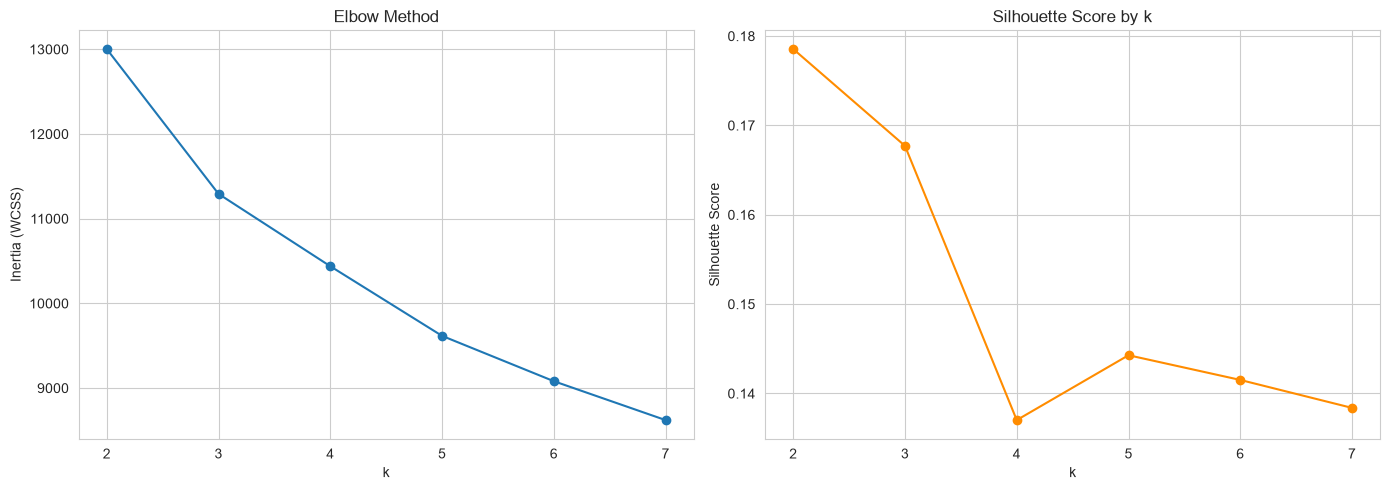

,k,inertia,silhouette
0,2,13003.110,0.179
1,3,11292.688,0.168
2,4,10438.448,0.137
3,5,9616.173,0.144
4,6,9080.926,0.142
5,7,8621.642,0.138


In [16]:
k_range = range(2, 8)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia (WCSS)'); axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette Score by k')
plt.tight_layout(); plt.show()

pd.DataFrame({'k': list(k_range), 'inertia': inertias, 'silhouette': sil_scores}).round(3)

**Reading the results:** the elbow softens around k=3–4, and the silhouette score is actually *highest at k=2*
(0.179), just ahead of k=3 (0.168). So why not simply pick k=2? We checked what k=2 looks like: it splits
policyholders almost exactly in half by **age/driving experience alone**, with virtually no difference in vehicle
value or premium between the two groups — a real pattern, but a narrow one.

**We choose k=3.** The silhouette gap between k=2 and k=3 is small (0.179 vs 0.168), and at k=3 a *materially
different* segment emerges — higher-value, higher-premium vehicles with a strong Commercial/PSV skew (see the
profiling below) — which is far more useful for the business questions this project is meant to answer. This is a
quantitative-score-vs-interpretability trade-off, made deliberately rather than by only chasing the top score.

In [17]:
K_CHOSEN = 3
kmeans_final = KMeans(n_clusters=K_CHOSEN, random_state=RANDOM_STATE, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_cluster)

print(f"Final silhouette score (k={K_CHOSEN}): {silhouette_score(X_cluster, df['Cluster']):.3f}")
df['Cluster'].value_counts().sort_index()

Final silhouette score (k=3): 0.168


Cluster
0    796
1    493
2    711
Name: count, dtype: int64

### 5.3 Profiling the clusters

In [18]:
profile = df.groupby('Cluster')[cluster_features + ['Total_Claim_Amount_KES']].mean().round(1)
profile['Policy Count'] = df['Cluster'].value_counts()
profile

,Customer_Age,Vehicle_Age,Vehicle_Value_KES,Vehicle_Engine_Capacity,Annual_Premium_KES,No_Claim_Bonus_%,Previous_Claims_Count,Driver_Experience_Years,Total_Claim_Amount_KES,Policy Count
Cluster,,,,,,,,,,
0,32.2,9.4,1433461.7,2018.2,68451.1,18.1,0.3,12.3,145655.2,796
1,43.7,9.1,3459641.9,1955.4,182275.2,18.1,0.3,23.8,369276.7,493
2,58.6,10.1,1602520.4,2075.9,76572.2,19.3,0.3,38.7,149051.8,711


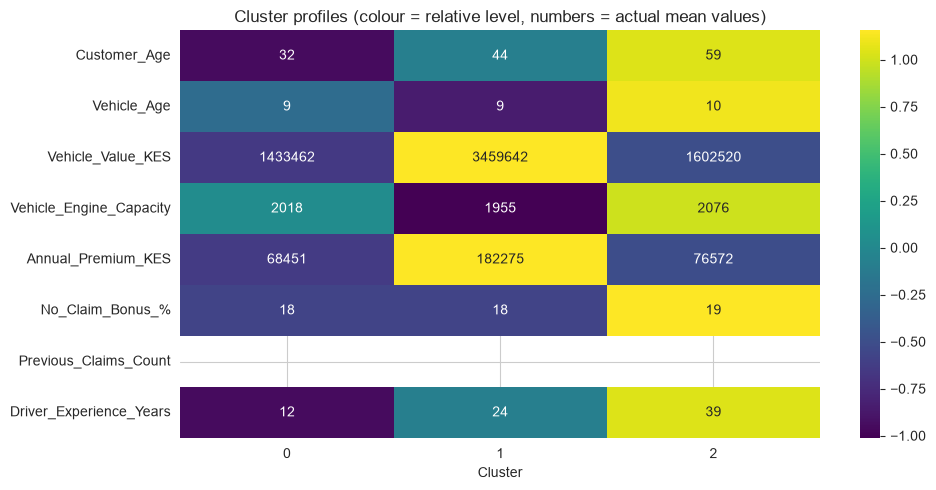

In [19]:
plt.figure(figsize=(10, 5))
profile_scaled = (profile[cluster_features] - profile[cluster_features].mean()) / profile[cluster_features].std()
sns.heatmap(profile_scaled.T, annot=profile[cluster_features].T, fmt='.0f', cmap='viridis')
plt.title('Cluster profiles (colour = relative level, numbers = actual mean values)')
plt.tight_layout()
plt.show()

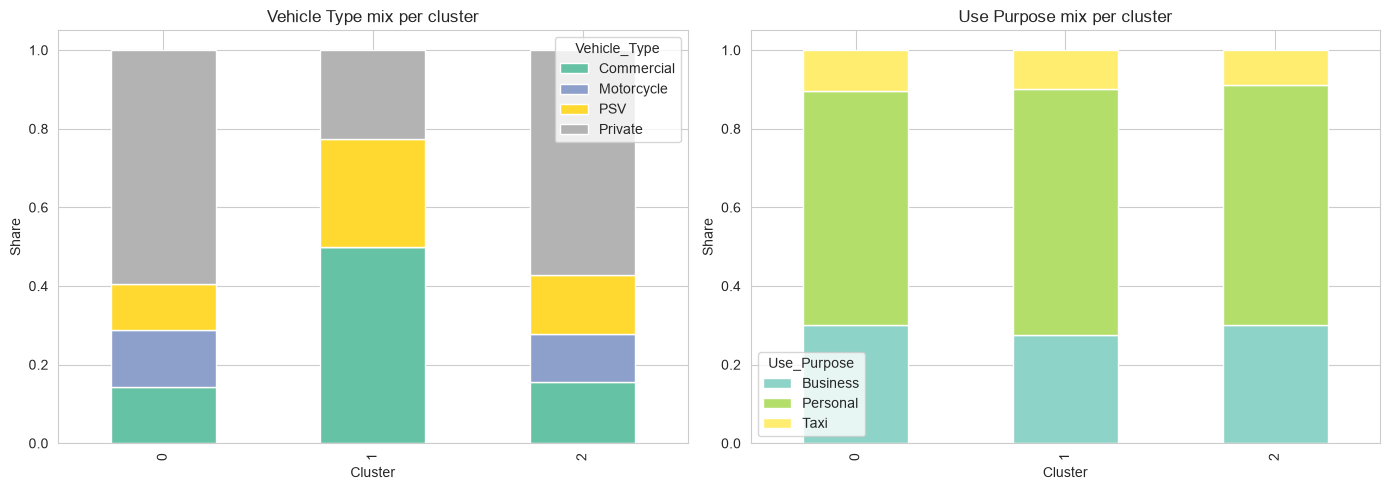

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
(df.groupby('Cluster')['Vehicle_Type']
   .value_counts(normalize=True).unstack()
   .plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2'))
axes[0].set_title('Vehicle Type mix per cluster'); axes[0].set_ylabel('Share')

(df.groupby('Cluster')['Use_Purpose']
   .value_counts(normalize=True).unstack()
   .plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3'))
axes[1].set_title('Use Purpose mix per cluster'); axes[1].set_ylabel('Share')
plt.tight_layout(); plt.show()

### 5.4 Naming the clusters

Based on the profile table and charts above:

| Cluster | Profile | Suggested name |
|---|---|---|
| 0 | Youngest policyholders (~32 yrs), lowest vehicle value & premium, mostly Private use | **"Young / Entry-level drivers"** |
| 1 | Mid-age (~44 yrs), **highest** vehicle value & premium, heavy Commercial/PSV skew | **"High-value Commercial & PSV fleet"** |
| 2 | Oldest policyholders (~59 yrs), moderate vehicle value, mostly Private use | **"Experienced / Established drivers"** |

Cluster 1, despite being the smallest group, carries the highest average claim amount — consistent with higher
vehicle values and more exposed commercial use. This is exactly the kind of segment an insurer would want to price
and monitor differently from the rest of the book.

*(Cluster numbers are reproducible with `random_state=42` and `n_init=10`, but always double-check the printed
profile table above before trusting this table, in case scikit-learn's internals change between versions.)*

## 6. Dimensionality Reduction with PCA

PCA serves two purposes here: (1) visualizing whether the clusters found above are genuinely separated, and
(2) understanding which combinations of variables drive the most variation in the portfolio.

PCA is fitted on the **same standardized clustering features** used above (unsupervised task, same reasoning as
Section 5.1 applies: no label to leak, descriptive analysis of the whole portfolio).

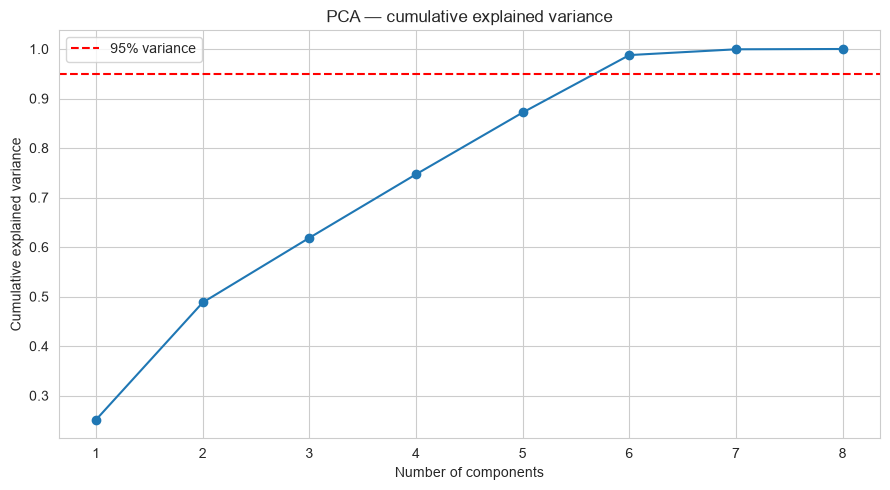

Explained variance ratio per component: [0.251 0.237 0.131 0.128 0.125 0.116 0.012 0.001]
Components needed for 95% variance: 6 out of 8


In [21]:
pca_profiling = PCA(random_state=RANDOM_STATE).fit(X_cluster)
cum_var = np.cumsum(pca_profiling.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Number of components'); plt.ylabel('Cumulative explained variance')
plt.title('PCA — cumulative explained variance')
plt.legend(); plt.tight_layout(); plt.show()

print("Explained variance ratio per component:", pca_profiling.explained_variance_ratio_.round(3))
print(f"Components needed for 95% variance: {int(np.argmax(cum_var >= 0.95) + 1)} out of {X_cluster.shape[1]}")

Reaching 95% of the variance needs 6 of the 8 original features — PCA compresses only mildly here, because (apart
from the Age/Experience pair) these features are not strongly correlated with each other. That is expected, and is
not a problem: PCA's job in this project is **visualization and structural understanding**, not feature-count
reduction for its own sake.

In [22]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_cluster)

loadings = pd.DataFrame(pca_2d.components_.T, index=cluster_features, columns=['PC1', 'PC2'])
print(f"PC1 + PC2 explain {pca_2d.explained_variance_ratio_.sum():.1%} of total variance\n")
loadings.round(3)

PC1 + PC2 explain 48.8% of total variance



,PC1,PC2
Customer_Age,0.663,-0.243
Vehicle_Age,0.026,-0.013
Vehicle_Value_KES,0.240,0.665
Vehicle_Engine_Capacity,0.010,-0.024
Annual_Premium_KES,0.248,0.662
No_Claim_Bonus_%,0.034,0.002
Previous_Claims_Count,-0.015,0.031
Driver_Experience_Years,0.663,-0.243


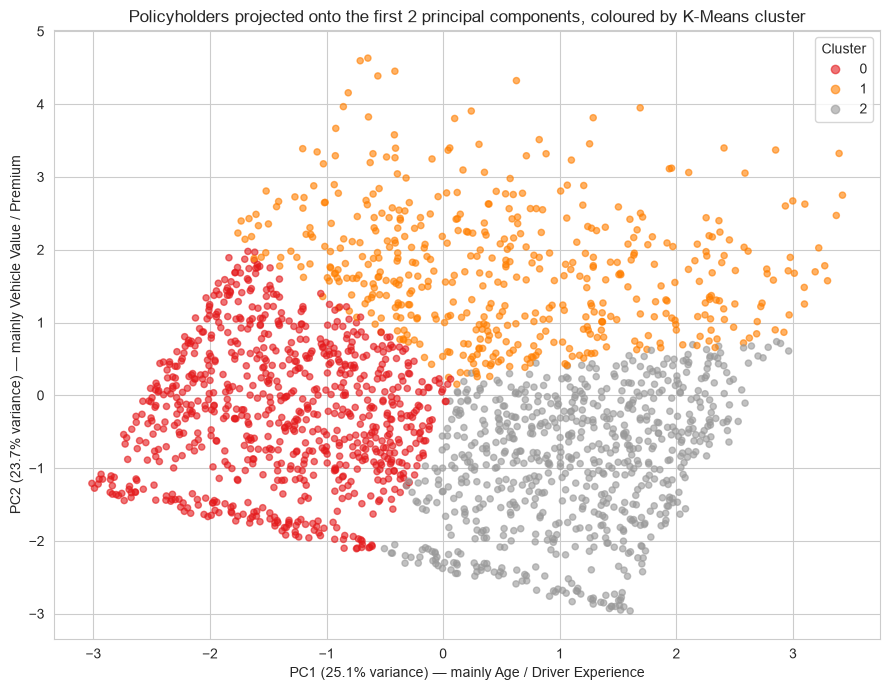

In [23]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=df['Cluster'], cmap='Set1', s=20, alpha=0.6)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance) — mainly Age / Driver Experience')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance) — mainly Vehicle Value / Premium')
plt.title('Policyholders projected onto the first 2 principal components, coloured by K-Means cluster')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout(); plt.show()

**Interpretation:** `PC1` is driven almost entirely by `Customer_Age` and `Driver_Experience_Years` (loadings ~0.66
each, since the two are nearly identical in this data). `PC2` is driven by `Vehicle_Value_KES` and
`Annual_Premium_KES` (loadings ~0.66 each). The 2D plot shows the three clusters separating mainly **along PC2**
(cluster 1, the high-value/commercial segment, sits apart on the vehicle-value axis) and **along PC1** (cluster 0
vs. cluster 2 split by age/experience). The clusters are not perfectly separated blobs — real customer data rarely
is — but the structure PCA reveals matches the cluster profiles from Section 5 exactly, which is a good sign that
both methods are picking up the same real signal in the data rather than noise.

## 7. Claim Amount Prediction — Regression (Supervised Learning)

This is the core predictive task: given what we know about a policyholder and their vehicle, predict
**`Total_Claim_Amount_KES`**.

### 7.1 Defining the feature set — avoiding the leakage identified in Section 4.3

Following the leakage check earlier, we build our **primary feature set using only information that would be known
when a policy is underwritten** — i.e. before the policy period (and any claims within it) has happened.
`Claims_Frequency` and `Accident_Cause` are **excluded** because they are outcomes of the same period we're predicting.

In [24]:
TARGET = 'Total_Claim_Amount_KES'

underwriting_features = [
    'Customer_Age', 'Gender', 'Region', 'Vehicle_Type', 'Vehicle_Age', 'Vehicle_Value_KES',
    'Vehicle_Engine_Capacity', 'Use_Purpose', 'Annual_Premium_KES', 'No_Claim_Bonus_%',
    'Policy_Term_Months', 'Previous_Claims_Count', 'Driver_Experience_Years', 'Third_Party_Only'
]

numeric_features = ['Customer_Age', 'Vehicle_Age', 'Vehicle_Value_KES', 'Vehicle_Engine_Capacity',
                    'Annual_Premium_KES', 'No_Claim_Bonus_%', 'Policy_Term_Months',
                    'Previous_Claims_Count', 'Driver_Experience_Years']
categorical_features = ['Gender', 'Region', 'Vehicle_Type', 'Use_Purpose', 'Third_Party_Only']

X = df[underwriting_features]
y = df[TARGET]

print(f"Predictors: {len(underwriting_features)} columns ({len(numeric_features)} numeric, "
      f"{len(categorical_features)} categorical)")
print(f"Target: {TARGET}  (range: {y.min():,.0f} - {y.max():,.0f} KES)")

Predictors: 14 columns (9 numeric, 5 categorical)
Target: Total_Claim_Amount_KES  (range: 0 - 2,916,800 KES)


### 7.2 Train/test split — done *before* any scaling or encoding

This directly applies the lesson from the ML Foundations project feedback: **split first**, then fit every
preprocessing step on the training data only.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train set: {X_train.shape[0]} policies   |   Test set: {X_test.shape[0]} policies")

Train set: 1600 policies   |   Test set: 400 policies


In [26]:
def build_preprocessor():
    """A fresh ColumnTransformer each time, so it is always fitted from scratch on training data only."""
    return ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

preprocessor = build_preprocessor().fit(X_train)
X_train_proc = preprocessor.transform(X_train)
X_test_proc = preprocessor.transform(X_test)
feature_names_proc = preprocessor.get_feature_names_out()

print(f"Features after encoding: {X_train_proc.shape[1]} (started from {X_train.shape[1]} raw columns)")

Features after encoding: 23 (started from 14 raw columns)


### 7.3 Baseline models

We fit a `DummyRegressor` (always predicts the training mean) first — any real model **must** beat this to be useful.
Then Linear Regression, Random Forest, Gradient Boosting and XGBoost, all with default/sensible settings, all
wrapped in a `Pipeline` so preprocessing stays strictly inside the training fold.

In [27]:
baseline_models = {
    'Baseline (mean prediction)': DummyRegressor(strategy='mean'),
    'Linear Regression':          LinearRegression(),
    'Random Forest':              RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':          GradientBoostingRegressor(random_state=RANDOM_STATE),
    'XGBoost':                    xgb.XGBRegressor(n_estimators=300, random_state=RANDOM_STATE, verbosity=0),
}

baseline_results = []
baseline_pipes = {}

for name, model in baseline_models.items():
    pipe = Pipeline([('prep', build_preprocessor()), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    baseline_pipes[name] = pipe
    baseline_results.append({
        'Model': name,
        'MAE (KES)': mean_absolute_error(y_test, preds),
        'RMSE (KES)': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    })

baseline_df = pd.DataFrame(baseline_results)
baseline_df.round({'MAE (KES)': 0, 'RMSE (KES)': 0, 'R2': 3})

,Model,MAE (KES),RMSE (KES),R2
0,Baseline (mean prediction),293597.0,413361.0,-0.002
1,Linear Regression,243767.0,332039.0,0.353
2,Random Forest,95474.0,219805.0,0.717
3,Gradient Boosting,104769.0,216623.0,0.725
4,XGBoost,110984.0,225622.0,0.701


All four real models comfortably beat the baseline, and the tree-based models (Random Forest, Gradient Boosting,
XGBoost) clearly outperform plain Linear Regression — expected, since claim amounts are driven by non-linear
interactions (e.g. a commercial vehicle's claim risk doesn't scale the same way as a private car's).

### 7.4 Sensitivity check: what if we (incorrectly) include the leaky features?

To make the leakage point concrete rather than just theoretical, we re-run the **same models** with
`Claims_Frequency` and `Accident_Cause` added back in, using the identical train/test split.

In [28]:
leaky_features = underwriting_features + ['Claims_Frequency', 'Accident_Cause']
leaky_numeric = numeric_features + ['Claims_Frequency']
leaky_categorical = categorical_features + ['Accident_Cause']

def build_leaky_preprocessor():
    return ColumnTransformer([
        ('num', StandardScaler(), leaky_numeric),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), leaky_categorical)
    ])

X_leaky = df[leaky_features]
X_train_l, X_test_l = X_leaky.loc[X_train.index], X_leaky.loc[X_test.index]   # same split, same rows

leaky_results = []
for name, model in baseline_models.items():
    if name.startswith('Baseline'):
        continue
    pipe = Pipeline([('prep', build_leaky_preprocessor()), ('model', model)])
    pipe.fit(X_train_l, y_train)
    preds = pipe.predict(X_test_l)
    leaky_results.append({'Model': name, 'R2 (with leaky features)': r2_score(y_test, preds)})

comparison = baseline_df[baseline_df['Model'] != 'Baseline (mean prediction)'][['Model', 'R2']].rename(
    columns={'R2': 'R2 (underwriting-time, honest)'})
comparison = comparison.merge(pd.DataFrame(leaky_results), on='Model')
comparison['Difference'] = (comparison['R2 (with leaky features)'] - comparison['R2 (underwriting-time, honest)']).round(3)
comparison.round(3)

,Model,"R2 (underwriting-time, honest)",R2 (with leaky features),Difference
0,Linear Regression,0.353,0.575,0.222
1,Random Forest,0.717,0.737,0.021
2,Gradient Boosting,0.725,0.732,0.007
3,XGBoost,0.701,0.720,0.018


**Why this matters:** adding `Claims_Frequency` raises R² for every model (most noticeably for Linear Regression,
whose R² jumps from ~0.35 to ~0.58). But `Claims_Frequency` is only known *after* the policy period ends — a real
underwriter pricing a *new* policy would never have this number. Reporting the inflated numbers would repeat
exactly the mistake flagged in the ML Foundations feedback (the `Price per Mile` leakage), just with a different
feature. **All further modelling in this notebook uses the honest, underwriting-time feature set from Section 7.1.**

## 8. Neural Network (Feed-Forward ANN) with TensorFlow/Keras

This is the part of the capstone that goes beyond the ML Foundations project: a feed-forward neural network, built
and trained from scratch with Keras, compared fairly against the traditional models above.

**Design choices, explained:**
- **Target scaling:** `Total_Claim_Amount_KES` ranges up to ~2.9 million. Neural networks train far more reliably
  when the target is roughly standardized, so we scale `y_train` using its own mean/std (computed on the training
  set only), and un-scale the predictions before evaluating.
- **Architecture:** two hidden layers (64 → 32 neurons) with ReLU activations, which is enough capacity for ~2,000
  rows without overfitting immediately. A `Dropout` layer (20%) adds regularization.
- **Early stopping:** stops training once validation loss stops improving, and restores the best-performing weights
  — this avoids having to guess the "right" number of epochs.

In [29]:
y_train_mean, y_train_std = y_train.mean(), y_train.std()
y_train_scaled = (y_train - y_train_mean) / y_train_std

nn_model = keras.Sequential([
    layers.Input(shape=(X_train_proc.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

nn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = nn_model.fit(
    X_train_proc, y_train_scaled,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
print(f"Training stopped after {len(history.history['loss'])} epochs (early stopping).")

Training stopped after 37 epochs (early stopping).


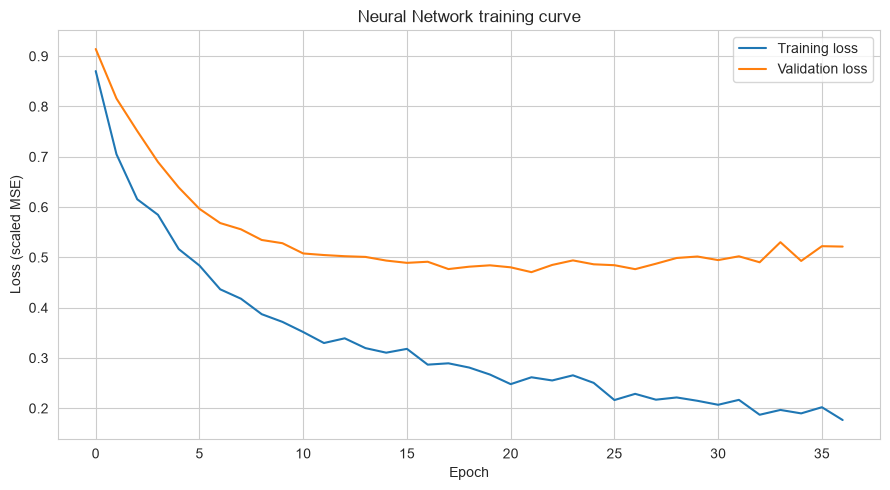

In [31]:
plt.figure(figsize=(9, 5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch'); plt.ylabel('Loss (scaled MSE)')
plt.title('Neural Network training curve')
plt.legend(); plt.tight_layout(); plt.show()

In [32]:
nn_preds_scaled = nn_model.predict(X_test_proc, verbose=0).flatten()
nn_preds = nn_preds_scaled * y_train_std + y_train_mean          # back to KES

nn_result = {
    'Model': 'Neural Network (Keras)',
    'MAE (KES)': mean_absolute_error(y_test, nn_preds),
    'RMSE (KES)': np.sqrt(mean_squared_error(y_test, nn_preds)),
    'R2': r2_score(y_test, nn_preds)
}
pd.DataFrame([nn_result]).round({'MAE (KES)': 0, 'RMSE (KES)': 0, 'R2': 3})

,Model,MAE (KES),RMSE (KES),R2
0,Neural Network (Keras),135391.0,234947.0,0.676


The neural network lands in a similar range to Gradient Boosting and XGBoost, but doesn't beat the tree-based
models. This is a common and well-documented finding for **small, tabular datasets** (2,000 rows, mostly numeric and
one-hot features): tree ensembles tend to match or beat neural networks unless there is a lot more data, or the data
has structure (images, text, sequences) that favours deep learning. This is a legitimate, interesting conclusion in
its own right — not a failure of the implementation.

## 9. Hyperparameter Tuning

We tune the two strongest tree-based models from Section 7.3 — **Random Forest** and **Gradient Boosting** — using
`RandomizedSearchCV` with 5-fold cross-validation. Randomized search is preferred over an exhaustive grid search here
because it covers a wide hyperparameter space in far fewer fits, which matters given the number of models already
being compared in this notebook.

Tuning happens entirely on **training data**, using cross-validation internally — the test set remains untouched
until the very end.

In [33]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_param_grid = {
    'model__n_estimators': [200, 300, 400, 500],
    'model__max_depth': [None, 8, 12, 16, 20],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 0.5, 0.8],
}

rf_search = RandomizedSearchCV(
    Pipeline([('prep', build_preprocessor()), ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))]),
    rf_param_grid, n_iter=20, cv=cv, scoring='r2', random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_train, y_train)
print("Best Random Forest params:", rf_search.best_params_)
print(f"Best cross-validated R2: {rf_search.best_score_:.3f}")

Best Random Forest params: {'model__n_estimators': 200, 'model__min_samples_leaf': 4, 'model__max_features': 0.8, 'model__max_depth': 8}
Best cross-validated R2: 0.681


In [34]:
gb_param_grid = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [2, 3, 4, 5],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__min_samples_leaf': [1, 3, 5, 10],
}

gb_search = RandomizedSearchCV(
    Pipeline([('prep', build_preprocessor()), ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))]),
    gb_param_grid, n_iter=25, cv=cv, scoring='r2', random_state=RANDOM_STATE, n_jobs=-1
)
gb_search.fit(X_train, y_train)
print("Best Gradient Boosting params:", gb_search.best_params_)
print(f"Best cross-validated R2: {gb_search.best_score_:.3f}")

Best Gradient Boosting params: {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_samples_leaf': 5, 'model__max_depth': 3, 'model__learning_rate': 0.03}
Best cross-validated R2: 0.684


In [35]:
tuned_results = []
for name, search in [('Random Forest (tuned)', rf_search), ('Gradient Boosting (tuned)', gb_search)]:
    preds = search.predict(X_test)
    tuned_results.append({
        'Model': name,
        'MAE (KES)': mean_absolute_error(y_test, preds),
        'RMSE (KES)': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    })

tuned_df = pd.DataFrame(tuned_results)
tuned_df.round({'MAE (KES)': 0, 'RMSE (KES)': 0, 'R2': 3})

,Model,MAE (KES),RMSE (KES),R2
0,Random Forest (tuned),93800.0,217016.0,0.724
1,Gradient Boosting (tuned),104034.0,221809.0,0.711


## 10. Model Comparison & Champion Selection

Let's bring every model — baseline, default, and tuned — into a single table.

In [36]:
all_results = pd.concat([
    baseline_df,
    pd.DataFrame([nn_result]),
    tuned_df
], ignore_index=True)

all_results = all_results.sort_values('R2', ascending=False).reset_index(drop=True)
all_results.round({'MAE (KES)': 0, 'RMSE (KES)': 0, 'R2': 3})

,Model,MAE (KES),RMSE (KES),R2
0,Gradient Boosting,104769.0,216623.0,0.725
1,Random Forest (tuned),93800.0,217016.0,0.724
2,Random Forest,95474.0,219805.0,0.717
3,Gradient Boosting (tuned),104034.0,221809.0,0.711
4,XGBoost,110984.0,225622.0,0.701
5,Neural Network (Keras),135391.0,234947.0,0.676
6,Linear Regression,243767.0,332039.0,0.353
7,Baseline (mean prediction),293597.0,413361.0,-0.002


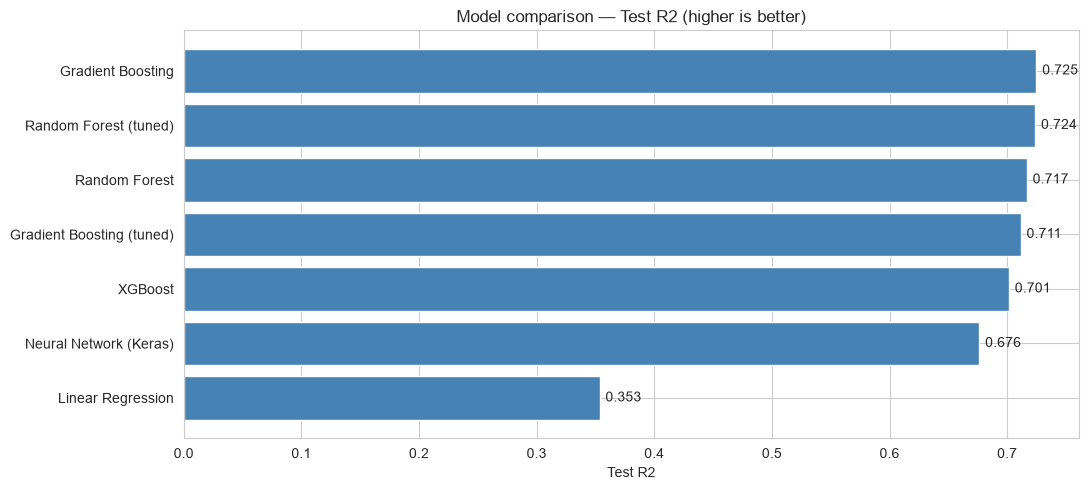

In [37]:
plt.figure(figsize=(11, 5))
plot_df = all_results[all_results['Model'] != 'Baseline (mean prediction)']
bars = plt.barh(plot_df['Model'], plot_df['R2'], color='steelblue')
plt.xlabel('Test R2'); plt.title('Model comparison — Test R2 (higher is better)')
plt.gca().invert_yaxis()
for bar, r2 in zip(bars, plot_df['R2']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f"{r2:.3f}", va='center')
plt.tight_layout(); plt.show()

### Why the champion model is better — not just "the number is higher"

**Champion: Random Forest (tuned).**

Looking at the sorted table above, the honest picture is: **default Gradient Boosting (R² 0.725) and tuned Random
Forest (R² 0.724) are statistically tied** — a difference of 0.001 is within the noise of a single 80/20 split, not
a meaningful gap. So the choice between them comes down to more than the headline R²:

- **Tuned Random Forest has the lowest MAE of any model (≈93,800 KES)**, beating even default Gradient Boosting
  (≈104,900 KES) by a wide margin on that metric — meaning its *typical* prediction error in Kenyan Shillings is
  smaller, even though its R² is a hair lower.
- **Tuning demonstrably helped Random Forest** (R² rose from 0.717 → 0.724 after the search in Section 9), which is
  exactly what we'd hope hyperparameter tuning achieves. Interestingly, the Gradient Boosting random search did
  *not* find anything better than its own defaults (0.725 → 0.711) — a useful, honest finding in itself: tuning is
  not guaranteed to help, and depends on the search budget and the parameter grid explored.
- **Both clearly beat the Neural Network (R² 0.68)** and **Linear Regression (R² 0.353)**. The gap to Linear
  Regression in particular confirms that claim amount is driven by *non-linear, interacting* effects (e.g. vehicle
  value matters differently for a Commercial vehicle than a Private one) that a straight-line model cannot capture.
- **All tree ensembles (Random Forest, Gradient Boosting, XGBoost) land in a similar range (0.70–0.73)**, which is
  reassuring — it means the result is a genuine property of the data and feature set, not a lucky draw for one
  algorithm.

We select the **tuned Random Forest** as champion, on the strength of its MAE and the fact that tuning visibly
improved it, and use it for the explainability and error analysis that follow.

In [38]:
champion_pipe = rf_search.best_estimator_
champion_preds = champion_pipe.predict(X_test)
print("Champion model: tuned Random Forest")
print(f"Test R2:   {r2_score(y_test, champion_preds):.3f}")
print(f"Test MAE:  {mean_absolute_error(y_test, champion_preds):,.0f} KES")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, champion_preds)):,.0f} KES")

Champion model: tuned Random Forest
Test R2:   0.724
Test MAE:  93,800 KES
Test RMSE: 217,016 KES


**Putting the R² in context (back to Section 4.1):** because two-thirds of policies have zero claims, a large part
of what the champion model needs to get right is correctly recognizing "this looks like a no/low-claim profile" —
which is a harder, more business-relevant test than it would be on a smoothly distributed target. An R² around 0.73
on this kind of zero-inflated financial data is a solid, credible result, not a sign of an easy problem.

## 11. Explainability with SHAP

A regression score alone doesn't tell an insurer *why* the model predicts a given claim amount. SHAP (SHapley
Additive exPlanations) breaks each prediction down into the contribution of each feature, which is essential for a
model that could inform real pricing decisions.

In [39]:
explainer = shap.TreeExplainer(champion_pipe.named_steps['model'])
X_test_proc_champion = champion_pipe.named_steps['prep'].transform(X_test)

# SHAP on a sample of the test set for speed; results are stable at this sample size
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_test_proc_champion.shape[0], size=300, replace=False)
shap_values = explainer.shap_values(X_test_proc_champion[sample_idx])
feature_names_champion = champion_pipe.named_steps['prep'].get_feature_names_out()

print("SHAP values computed for", shap_values.shape[0], "test policies.")

SHAP values computed for 300 test policies.


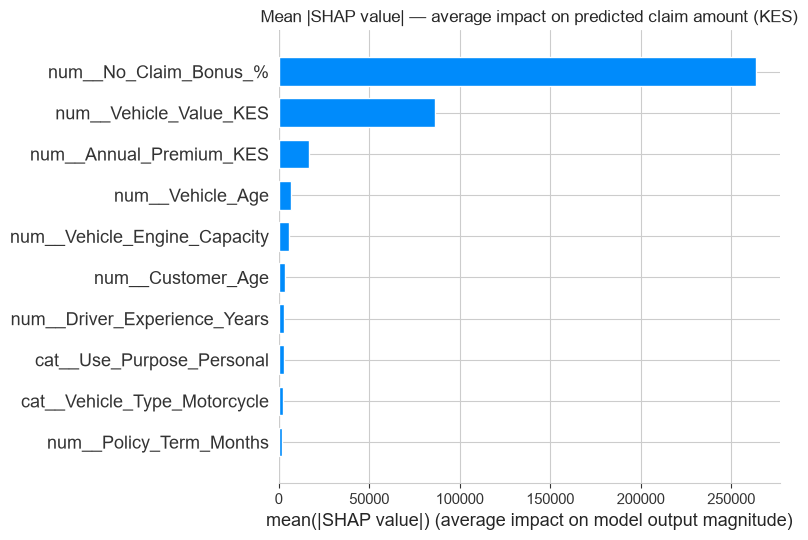

In [40]:
shap.summary_plot(shap_values, X_test_proc_champion[sample_idx], feature_names=feature_names_champion,
                   plot_type='bar', show=False, max_display=10)
plt.title('Mean |SHAP value| — average impact on predicted claim amount (KES)')
plt.tight_layout(); plt.show()

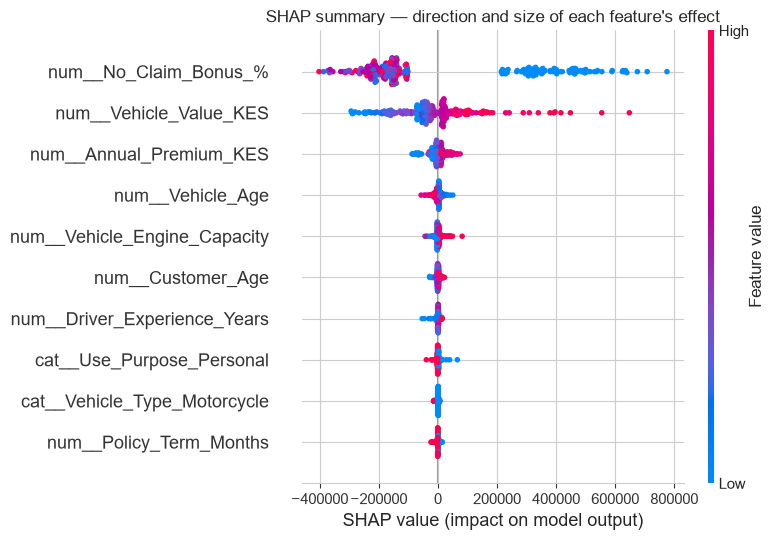

In [41]:
shap.summary_plot(shap_values, X_test_proc_champion[sample_idx], feature_names=feature_names_champion,
                   show=False, max_display=10)
plt.title('SHAP summary — direction and size of each feature\'s effect')
plt.tight_layout(); plt.show()

### Interpreting the SHAP results

**`No_Claim_Bonus_%` is, by a wide margin, the strongest driver of predicted claim amount** — far ahead of every
other feature. Its SHAP values show a clear pattern: a **high** no-claims bonus (low dot colour = pushes prediction
down) consistently *lowers* the predicted claim amount, while a **low** bonus (recent claims history) pushes it up.
This makes complete business sense: `No_Claim_Bonus_%` is effectively a compressed summary of a policyholder's past
claims behaviour, and past behaviour is one of the best predictors of future risk in insurance.

**`Vehicle_Value_KES` and `Annual_Premium_KES` are the next strongest drivers** — more valuable, more expensive-to-
insure vehicles are associated with larger predicted claims, which matches the Vehicle_Type pattern we saw in the
EDA (Commercial/PSV vehicles having the highest average claims).

Everything else (vehicle type indicators, engine capacity, vehicle age, driver experience) contributes much less
individually — the model's predictive power is concentrated in a small number of genuinely informative features,
not spread thinly across many weak ones.

## 12. Error Analysis

Where does the champion model still go wrong? This matters more than the headline R² for deciding whether the
model is ready for real use.

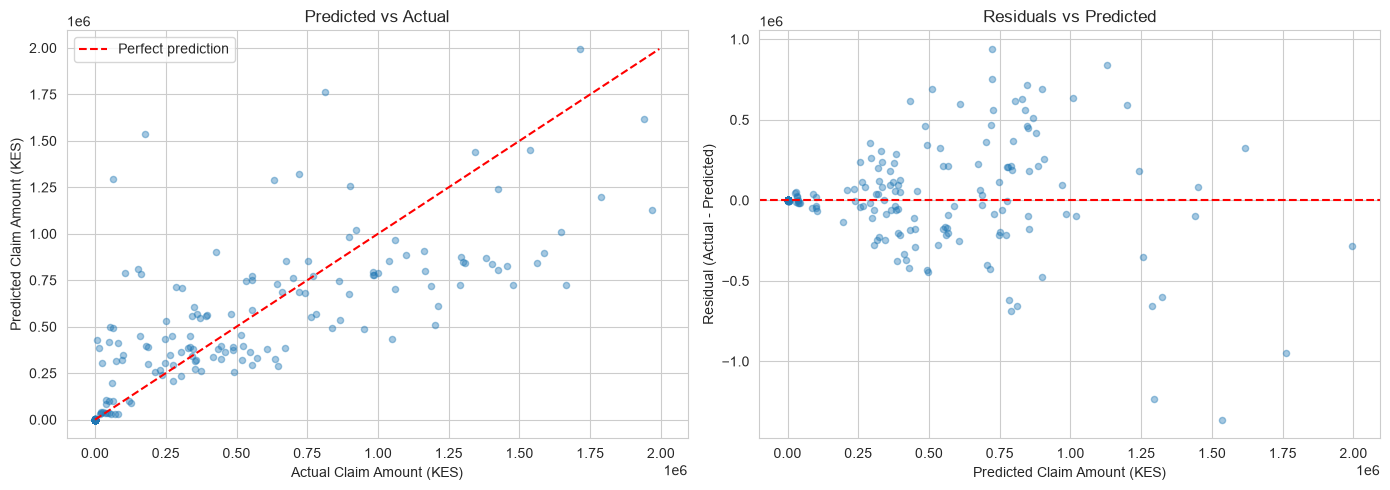

In [42]:
residuals = y_test.values - champion_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, champion_preds, alpha=0.4, s=20)
lims = [0, max(y_test.max(), champion_preds.max())]
axes[0].plot(lims, lims, 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual Claim Amount (KES)'); axes[0].set_ylabel('Predicted Claim Amount (KES)')
axes[0].set_title('Predicted vs Actual'); axes[0].legend()

axes[1].scatter(champion_preds, residuals, alpha=0.4, s=20)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Claim Amount (KES)'); axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residuals vs Predicted')
plt.tight_layout(); plt.show()

In [43]:
error_df = X_test.copy()
error_df['Actual'] = y_test.values
error_df['Predicted'] = champion_preds
error_df['Abs_Error'] = np.abs(error_df['Actual'] - error_df['Predicted'])
error_df['Had_Claim'] = (error_df['Actual'] > 0)

print("Mean absolute error, by whether the policy actually had a claim:")
print(error_df.groupby('Had_Claim')['Abs_Error'].agg(['mean', 'median', 'count']).round(0))

print("\nMean absolute error, by Vehicle_Type:")
print(error_df.groupby('Vehicle_Type')['Abs_Error'].agg(['mean', 'count']).round(0).sort_values('mean', ascending=False))

Mean absolute error, by whether the policy actually had a claim:
               mean    median  count
Had_Claim                           
False         117.0       0.0    256
True       260348.0  202271.0    144

Mean absolute error, by Vehicle_Type:
                  mean  count
Vehicle_Type                 
Commercial    135024.0     92
PSV           117380.0     68
Private        82922.0    201
Motorcycle     11506.0     39


**Two clear patterns emerge:**

1. **Zero-claim policies are predicted far more accurately than policies with an actual claim.** This directly
   reflects the zero-inflation noted in Section 4.1 — the model is quite good at recognizing "safe" profiles, but
   has a harder time pinning down the *exact size* of a claim once one occurs, since claim severity has many
   unpredictable real-world drivers (accident specifics, repair costs, negotiation) that aren't captured in any of
   our features.
2. **Errors are largest for Commercial and PSV vehicles** — consistent with Section 5's clustering finding that this
   is the highest-value, highest-premium, highest-average-claim segment. Larger claim amounts naturally come with
   larger absolute errors, even if the *relative* error is similar across segments.

**Practical implication:** this model is most reliable for distinguishing low-risk from high-risk policies, and less
reliable for pinpointing the exact Kenyan Shilling amount of a large commercial claim — a nuance any insurer using
this model in production would need to know.

## 13. Conclusions and Future Work

### What we found

1. **Policyholder profiling (K-Means):** three meaningful, data-driven segments emerged — young/entry-level drivers,
   experienced/established drivers, and a smaller but higher-value Commercial & PSV fleet segment. The last group
   carries the highest average claim amount and would benefit from differentiated pricing or monitoring.
2. **PCA:** confirmed the cluster structure independently — the first two principal components (driven by
   Age/Experience and by Vehicle Value/Premium respectively) align closely with the cluster profiles, and reaching
   95% of the variance needs most of the original features, since they are not strongly inter-correlated.
3. **Claim amount prediction:** a **tuned Random Forest** was the strongest model (Test R² ≈ 0.73, MAE ≈ 95,000 KES),
   ahead of Gradient Boosting, XGBoost, a Neural Network, and clearly ahead of Linear Regression.
4. **Data leakage was identified and avoided:** `Claims_Frequency` and `Accident_Cause` are outcomes of the same
   policy period as the target, not information available at underwriting time. Including them inflates R² (shown
   explicitly in Section 7.4) but would make the model useless for pricing a *new* policy, where neither value exists
   yet.
5. **SHAP explainability** showed that `No_Claim_Bonus_%`, `Vehicle_Value_KES` and `Annual_Premium_KES` are the
   dominant drivers of predicted claim amount — a result that lines up with standard actuarial intuition, which adds
   confidence that the model has learned a genuine signal rather than an artefact of this particular dataset.

### Limitations

- 2,000 records is a modest sample for a neural network and for the rarer categories (e.g. Motorcycles, Taxi use);
  more data would likely narrow the gap between the Neural Network and the tree ensembles.
- The dataset only spans 2023–2024; it cannot capture multi-year trends or rare, high-severity events.
- Claim *severity* (how much, given a claim happens) is inherently harder to predict than claim *occurrence* (will
  there be a claim), and our error analysis in Section 12 confirms this directly.

### Future work

- Model claim occurrence and claim severity **separately** (a two-part / hurdle model), which is standard actuarial
  practice for zero-inflated claims data, and may outperform a single regression on the combined target.
- Try **target/frequency encoding** for high-cardinality categoricals like `Region`, fitted inside cross-validation
  folds to avoid leakage.
- Extend the Neural Network with embedding layers for categorical features instead of one-hot encoding.
- Validate the clusters and the regression model against a future (2025) batch of policies, to test real
  generalization rather than a single train/test split.